TASK 1

Errore è 4e-06


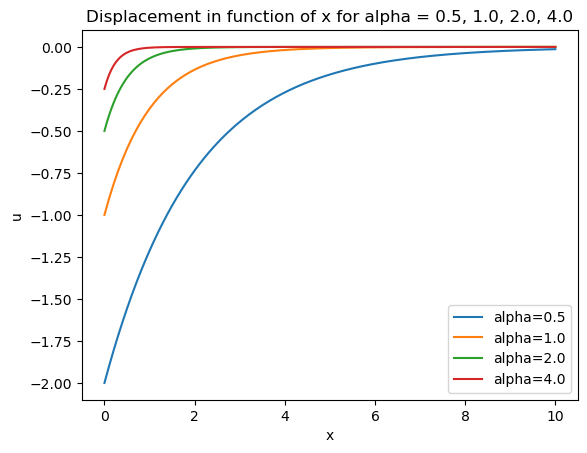

In [3]:
#!/usr/bin/env python

import numpy as np
import matplotlib.pyplot as plt

"""
Created: 2025/11/12 11:19:40
Last modified: 2025/11/12 11:53:33
Author: Francesco Bolzonella (francesco.bolzonella.1@studenti.unipd.it)
"""
# PREPROCESSOR

# Discretization definition
n_nodes = 200
x_values = np.linspace(0.0, 10.0, n_nodes)

# Constants of the bar in the domain x = 0 - 10
P, E, A = 1.0, 1.0, 1.0
L = 5.0
c = P * A / (L**2)
alpha_values = [
    0.5,
    1.0,
    2.0,
    4.0,
]
u = np.zeros((len(alpha_values), len(x_values)))

for i, alpha in enumerate(alpha_values):
    for j, x in enumerate(x_values):
        u[i, j] = -P / (E * A * alpha) * np.exp(-alpha * x)

# E_L2 computation
h = 10 / np.size(x_values) # dimension of the single element
E_L2 = (c*h)**2
print(f"Errore è {E_L2}")

# Plot of the graphs
for i in range(0, 4):
    plt.plot(x_values, u[i, :], label=f"alpha={alpha_values[i]}")
    plt.xlabel("x")
    plt.ylabel("u")
    plt.title("Displacement in function of x for alpha = 0.5, 1.0, 2.0, 4.0")
plt.legend()

TASK 2 (bar_1D with 2 nodes)

In [5]:
#!/usr/bin/env python

import numpy as np

import pyfem


def main() -> np.ndarray:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    bar_length = 10.0
    num_nodes = 2
    num_elements = 1
    P = 1.0
    E = 1.0
    A = 1.0
    alpha = 1.0

    # Nodal coordinates
    points = np.array([0.0, bar_length])

    # Element connectivity (which nodes belong to each element)
    element_connectivity = [
        [0, 1],
    ]

    # 2. Element properties

    # Define element properties registry
    element_properties = pyfem.make_element_properties(
        [
            ("bar", ("bar_1D", {"E": 1.0, "A": 1.0, "k": 1.0})),
        ]
    )

    # Assign properties to elements
    element_property_labels = ["bar"]

    # 3. Mesh

    # Create mesh
    mesh = pyfem.Mesh(
        num_nodes=num_nodes,
        points=points,
        num_elements=num_elements,
        element_connectivity=element_connectivity,
        element_property_labels=element_property_labels,
    )

    # Define node sets
    mesh.add_node_set(tag=1, nodes={0}, name="left_end")
    mesh.add_node_set(tag=2, nodes={1}, name="right_end")

    print("\n- Node sets:")
    for tag, node_set in mesh.node_sets.items():
        print(f"  {node_set}")

    # 4. Create Model

    problem = pyfem.Problem(
        pyfem.Physics.MECHANICS,
        pyfem.Dimension.D1,
    )

    model = pyfem.Model(mesh, problem)
    model.set_element_properties(element_properties)
    print(model)

    # 5. Boundary conditions

    # Dirichlet boundary conditions (prescribed displacements)
    model.bc.prescribe_displacement("right_end", pyfem.DOFType.U_X, (-(P/(E*A*alpha))*np.exp(-alpha*10.0)))

    # Neumann boundary conditions (applied forces)
    model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

    print(f"\n- Prescribed displacements: {model.bc.prescribed_displacements}")
    print(f"- Applied forces: {model.bc.applied_forces}")

    # PROCESSING: Solve FEA problem

    # Create solver
    solver = pyfem.LinearStaticSolver(model)

    # Assemble the global stiffness matrix
    solver.assemble_global_matrix()

    # Apply boundary conditions
    solver.apply_boundary_conditions()

    # Solve for nodal displacements
    nodal_displacements, original_global_stiffness_matrix = solver.solve()

    # POSTPROCESSING: Compute derived quantities

    # Create postprocessor
    postprocessor = pyfem.PostProcessor(
        model.mesh,
        model.element_properties,
        original_global_stiffness_matrix,
        nodal_displacements,
    )

    # Compute strain energy
    postprocessor.compute_strain_energy_global()

    return nodal_displacements


if __name__ == "__main__":
    main()



- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 2 nodes, 1 elements
  Degrees of Freedom: 2
  Node Sets: 2

- Prescribed displacements: [(1, np.float64(-4.5399929762484854e-05))]
- Applied forces: [(0, -1.0)]

Solver Statistics
  System size (DOFs):           2
  Matrix shape:                 2 × 2
  Total matrix entries:         4
  Non-zero entries:             2
  Sparsity (% zeros):           50.00%
  Matrix memory usage:          32 bytes (0.00 MiB)

- Total strain energy in the system (from global computation): 0.14563107076273313


TASK 2 (bar_1D with 3 nodes)

In [4]:
#!/usr/bin/env python

import numpy as np

import pyfem


def main() -> np.ndarray:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    bar_length = 10.0
    num_nodes = 3
    num_elements = 1
    P = 1.0
    E = 1.0
    A = 1.0
    alpha = 1.0

    # Nodal coordinates
    points = np.array([0.0, bar_length/2.0, bar_length,])

    # Element connectivity (which nodes belong to each element)
    element_connectivity = [
        [0, 1, 2],
    ]

    # 2. Element properties

    # Define element properties registry
    element_properties = pyfem.make_element_properties(
        [
            ("bar", ("bar3_1D", {"E": 1.0, "A": 1.0, "k": 1.0})),
        ]
    )

    # Assign properties to elements
    element_property_labels = ["bar"]

    # 3. Mesh

    # Create mesh
    mesh = pyfem.Mesh(
        num_nodes=num_nodes,
        points=points,
        num_elements=num_elements,
        element_connectivity=element_connectivity,
        element_property_labels=element_property_labels,
    )

    # Define node sets
    mesh.add_node_set(tag=1, nodes={0}, name="left_end")
    mesh.add_node_set(tag=2, nodes={2}, name="right_end")

    print("\n- Node sets:")
    for tag, node_set in mesh.node_sets.items():
        print(f"  {node_set}")

    # 4. Create Model

    problem = pyfem.Problem(
        pyfem.Physics.MECHANICS,
        pyfem.Dimension.D1,
    )

    model = pyfem.Model(mesh, problem)
    model.set_element_properties(element_properties)
    print(model)

    # 5. Boundary conditions

    # Dirichlet boundary conditions (prescribed displacements)
    model.bc.prescribe_displacement("right_end", pyfem.DOFType.U_X, (-(P/(E*A*alpha))*np.exp(-alpha*10.0)))

    # Neumann boundary conditions (applied forces)
    model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

    print(f"\n- Prescribed displacements: {model.bc.prescribed_displacements}")
    print(f"- Applied forces: {model.bc.applied_forces}")

    # PROCESSING: Solve FEA problem

    # Create solver
    solver = pyfem.LinearStaticSolver(model)

    # Assemble the global stiffness matrix
    solver.assemble_global_matrix()

    # Apply boundary conditions
    solver.apply_boundary_conditions()

    # Solve for nodal displacements
    nodal_displacements, original_global_stiffness_matrix = solver.solve()

    # POSTPROCESSING: Compute derived quantities

    # Create postprocessor
    postprocessor = pyfem.PostProcessor(
        model.mesh,
        model.element_properties,
        original_global_stiffness_matrix,
        nodal_displacements,
    )

    # Compute strain energy
    postprocessor.compute_strain_energy_global()

    return nodal_displacements


if __name__ == "__main__":
    main()



- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 3 nodes, 1 elements
  Degrees of Freedom: 3
  Node Sets: 2

- Prescribed displacements: [(2, np.float64(-4.5399929762484854e-05))]
- Applied forces: [(0, -1.0)]

Solver Statistics
  System size (DOFs):           3
  Matrix shape:                 3 × 3
  Total matrix entries:         9
  Non-zero entries:             5
  Sparsity (% zeros):           44.44%
  Matrix memory usage:          72 bytes (0.00 MiB)

- Total strain energy in the system (from global computation): 0.32480315112105773


TASK 3

In [3]:
#!/usr/bin/env python

import numpy as np

import pyfem


def genera_connettivita_uniforme(Ne: int) -> list:
    """
    Genera la connettività per una mesh 1D uniforme con Ne elementi a due nodi.

    Args:
        Ne: Numero di elementi.

    Returns:
        Una lista di liste che definisce la connettività degli elementi.
    """

    # 1. Crea un array di indici da 0 a Ne (i nodi iniziali)
    nodi_iniziali = np.arange(Ne)  # [0, 1, 2, ..., Ne-1]

    # 2. Crea un array per i nodi finali (da 1 a Ne)
    nodi_finali = np.arange(1, Ne + 1)  # [1, 2, 3, ..., Ne]

    # 3. Combina i due array in una lista di coppie (connettività)
    #    numpy.column_stack crea una matrice a due colonne,
    #    poi la convertiamo in una lista di liste.
    element_connectivity = np.column_stack((nodi_iniziali, nodi_finali)).tolist()

    return element_connectivity


def main() -> np.ndarray:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    L = 10.0
    number_elements = [4, 8, 16, 32, 64]
    P = 1.0
    E = 1.0
    A = 1.0
    alpha = 1.0

    # 2. Element properties

    # Define element properties registry
    element_properties = pyfem.make_element_properties(
        [
            ("bar", ("bar_1D", {"E": 1.0, "A": 1.0, "k": 1.0})),
        ]
    )

    for Ne in number_elements:
        num_elements = Ne

        # Assign properties to elements
        element_property_labels = ["bar"] * num_elements

        # 1. Calcola Nodi e Punti
        num_nodes = Ne + 1
        points = np.linspace(0.0, 10.0, num_nodes)

        # 2. Genera la Connettività
        element_connectivity = genera_connettivita_uniforme(Ne)

        print("elem connec: ", element_connectivity)

        # 3. Mesh

        # Create mesh
        mesh = pyfem.Mesh(
            num_nodes=num_nodes,
            points=points,
            num_elements=num_elements,
            element_connectivity=element_connectivity,
            element_property_labels=element_property_labels,
        )

        # Define node sets
        mesh.add_node_set(tag=1, nodes={0}, name="left_end")
        mesh.add_node_set(tag=2, nodes={num_nodes - 1}, name="right_end")

        print("\n- Node sets:")
        for tag, node_set in mesh.node_sets.items():
            print(f"  {node_set}")

        # 4. Create Model

        problem = pyfem.Problem(
            pyfem.Physics.MECHANICS,
            pyfem.Dimension.D1,
        )

        model = pyfem.Model(mesh, problem)
        model.set_element_properties(element_properties)
        print(model)

        # 5. Boundary conditions

        # Dirichlet boundary conditions (prescribed displacements)
        model.bc.prescribe_displacement(
            "right_end",
            pyfem.DOFType.U_X,
            (-(P / (E * A * alpha)) * np.exp(-alpha * 10.0)),
        )

        # Neumann boundary conditions (applied forces)
        model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

        print(f"\n- Prescribed displacements: {model.bc.prescribed_displacements}")
        print(f"- Applied forces: {model.bc.applied_forces}")

        # PROCESSING: Solve FEA problem

        # Create solver
        solver = pyfem.LinearStaticSolver(model)

        # Assemble the global stiffness matrix
        solver.assemble_global_matrix()

        # Apply boundary conditions
        solver.apply_boundary_conditions()

        # Solve for nodal displacements
        nodal_displacements, original_global_stiffness_matrix = solver.solve()

        # POSTPROCESSING: Compute derived quantities

        # Create postprocessor
        postprocessor = pyfem.PostProcessor(
            model.mesh,
            model.element_properties,
            original_global_stiffness_matrix,
            nodal_displacements,
        )

        # Compute strain energy
        postprocessor.compute_strain_energy_global()

    return nodal_displacements


if __name__ == "__main__":
    main()


elem connec:  [[0, 1], [1, 2], [2, 3], [3, 4]]

- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 5 nodes, 4 elements
  Degrees of Freedom: 5
  Node Sets: 2

- Prescribed displacements: [(4, np.float64(-4.5399929762484854e-05))]
- Applied forces: [(0, -1.0)]

Solver Statistics
  System size (DOFs):           5
  Matrix shape:                 5 × 5
  Total matrix entries:         25
  Non-zero entries:             11
  Sparsity (% zeros):           56.00%
  Matrix memory usage:          200 bytes (0.00 MiB)

- Total strain energy in the system (from global computation): 0.4054424283106203
elem connec:  [[0, 1], [1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7], [7, 8]]

- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 9 nodes, 8 elements
 

TASK 4